In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import pyXLMS
from pyXLMS.data import create_csm
from pyXLMS.parser.util import format_sequence
from pyXLMS.parser.util import get_bool_from_value

from typing import List
from typing import Dict
from typing import Any
from typing import Literal

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV48.csv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

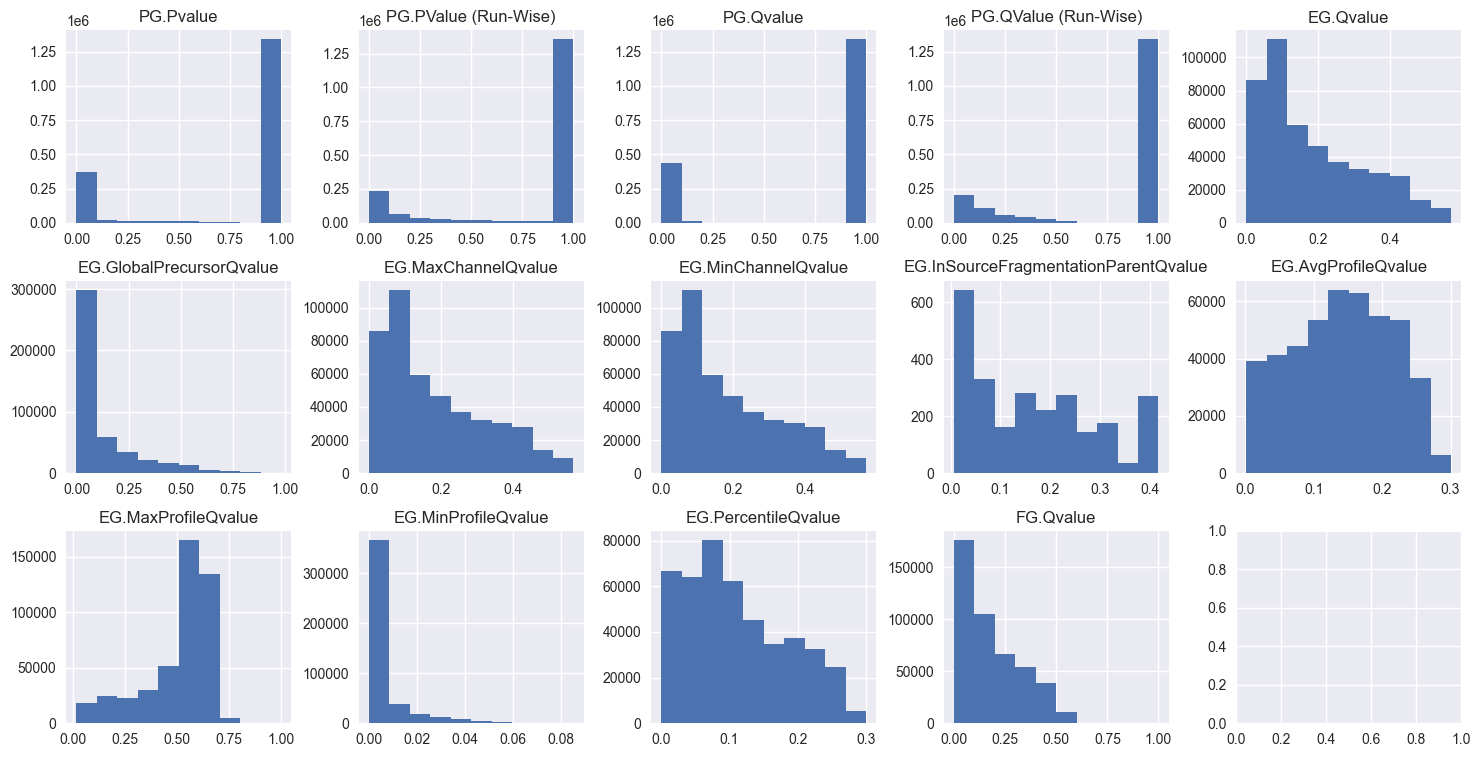

In [3]:
fig, ax = plt.subplots(3, 5, figsize=(18, 9))
df.hist("PG.Pvalue", bins=10, ax=ax[0, 0])
df.hist("PG.PValue (Run-Wise)", bins=10, ax=ax[0, 1])
df.hist("PG.Qvalue", bins=10, ax=ax[0, 2])
df.hist("PG.QValue (Run-Wise)", bins=10, ax=ax[0, 3])
df.hist("EG.Qvalue", bins=10, ax=ax[0, 4])
df.hist("EG.GlobalPrecursorQvalue", bins=10, ax=ax[1, 0])
df.hist("EG.MaxChannelQvalue", bins=10, ax=ax[1, 1])
df.hist("EG.MinChannelQvalue", bins=10, ax=ax[1, 2])
df.hist("EG.InSourceFragmentationParentQvalue", bins=10, ax=ax[1, 3])
df.hist("EG.AvgProfileQvalue", bins=10, ax=ax[1, 4])
df.hist("EG.MaxProfileQvalue", bins=10, ax=ax[2, 0])
df.hist("EG.MinProfileQvalue", bins=10, ax=ax[2, 1])
df.hist("EG.PercentileQvalue", bins=10, ax=ax[2, 2])
df.hist("FG.Qvalue", bins=10, ax=ax[2, 3]);

In [4]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV48.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)

In [5]:
def read_csms(
    df: pd.DataFrame,
    score: Literal[
        "EG.Cscore",
        "PP.CompositeRelativeMatchScore",
        "PP.CompositePartialCscore",
        "PP.UniScoreFull",
    ],
) -> List[Dict[str, Any]]:
    csms = list()
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Reading CSMs..."):
        if score == "PP.CompositeRelativeMatchScore":
            score_a = float(row["PP.RelativeMatchScoreA"])
            score_b = float(row["PP.RelativeMatchScoreB"])
            score_csm = float(row["PP.CompositeRelativeMatchScore"])
        elif score == "PP.CompositePartialCscore":
            score_a = float(row["PP.PartialCscoreA"])
            score_b = float(row["PP.PartialCscoreB"])
            score_csm = float(row["PP.CompositePartialCscore"])
        elif score == "PP.UniScoreFull":
            score_a = float(row["PP.UniScoreAlpha"])
            score_b = float(row["PP.UniScoreBeta"])
            score_csm = float(row["PP.UniScoreFull"])
        else:
            score_a = float(row["EG.Cscore"])
            score_b = float(row["EG.Cscore"])
            score_csm = float(row["EG.Cscore"])
        csm = create_csm(
            peptide_a=format_sequence(row["PP.PeptideA"]),
            modifications_a=None,
            xl_position_peptide_a=int(row["PP.CrosslinkPositionPeptideA"]),
            proteins_a=str(row["PP.ProteinA"]).split(";"),
            xl_position_proteins_a=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinA"]).split(";")
            ],
            pep_position_proteins_a=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinA"]).split(";")
            ],
            score_a=score_a,
            decoy_a=get_bool_from_value(row["PP.IsDecoyA"]),
            peptide_b=format_sequence(row["PP.PeptideB"]),
            modifications_b=None,
            xl_position_peptide_b=int(row["PP.CrosslinkPositionPeptideB"]),
            proteins_b=str(row["PP.ProteinB"]).split(";"),
            xl_position_proteins_b=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinB"]).split(";")
            ],
            pep_position_proteins_b=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinB"]).split(";")
            ],
            score_b=score_b,
            decoy_b=get_bool_from_value(row["PP.IsDecoyB"]),
            score=score_csm,
            spectrum_file=f"{row['R.Condition'].strip()}:{row['R.FileName'].strip()}",
            scan_nr=int(row["PP.PseudoScanNumber"]),
            charge=int(row["FG.Charge"]),
            rt=None,
            im_cv=None,
        )
        csms.append(csm)
    return csms


def pipeline(csms: List[Dict[str, Any]], fdr=0.01) -> List[Dict[str, Any]]:
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr=fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [6]:
df["R.Condition"].value_counts()

R.Condition
DIA12_CV48    14480
Name: count, dtype: int64

In [7]:
cscore = read_csms(df, score="EG.Cscore")
pcscore = read_csms(df, score="PP.CompositePartialCscore")
mscore = read_csms(df, score="PP.CompositeRelativeMatchScore")
uniscore = read_csms(df, score="PP.UniScoreFull")

Reading CSMs...: 100%|████████████████████████████████████████████████████████| 14480/14480 [00:01<00:00, 12495.47it/s]


In [8]:
_ = pyXLMS.exporter.to_xifdr(cscore, filename="xiFDR/CV48/Cscore_CV48.csv")
_ = pyXLMS.exporter.to_xifdr(pcscore, filename="xiFDR/CV48/Partial_Cscore_CV48.csv")
_ = pyXLMS.exporter.to_xifdr(mscore, filename="xiFDR/CV48/Match_Score_CV48.csv")
_ = pyXLMS.exporter.to_xifdr(uniscore, filename="xiFDR/CV48/UniScore_CV486.csv")

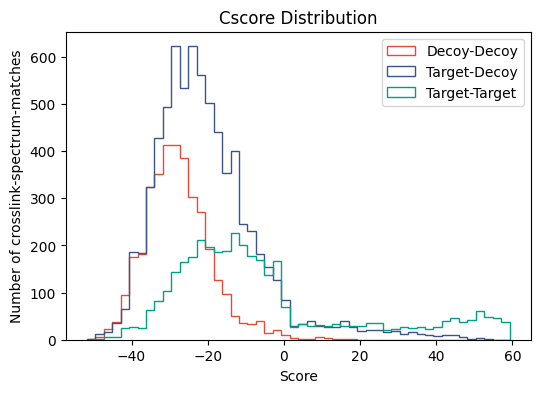

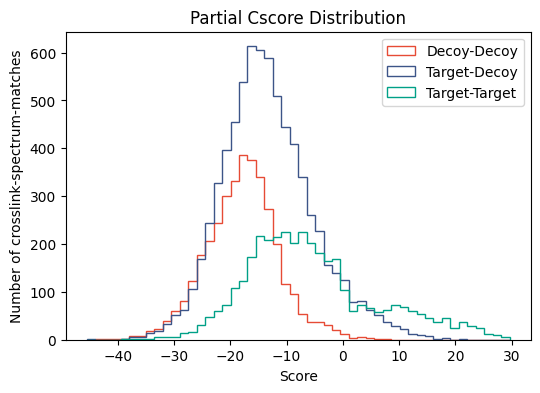

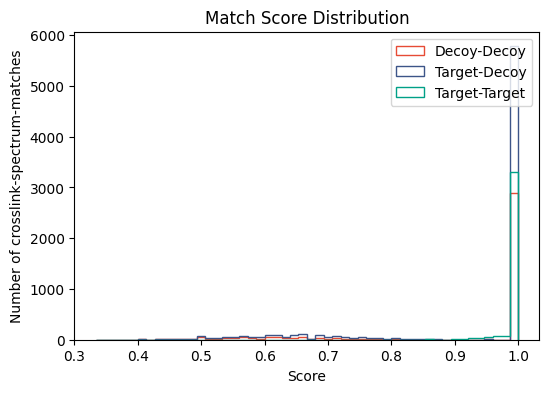

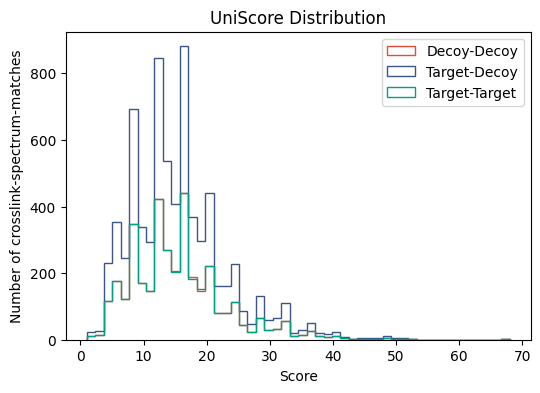

In [9]:
plt.style.use("default")

fig, ax = pyXLMS.plotting.plot_score_distribution(
    cscore,
    bins=50,
    title="Cscore Distribution",
    figsize=(6, 4),
    filename_prefix="plots/CV48/Cscore_Distribution_CV48",
)
fig, ax = pyXLMS.plotting.plot_score_distribution(
    pcscore,
    bins=50,
    title="Partial Cscore Distribution",
    figsize=(6, 4),
    filename_prefix="plots/CV48/Partial_Cscore_Distribution_CV48",
)
fig, ax = pyXLMS.plotting.plot_score_distribution(
    mscore,
    bins=50,
    title="Match Score Distribution",
    figsize=(6, 4),
    filename_prefix="plots/CV48/Match_Score_Distribution_CV48",
)
fig, ax = pyXLMS.plotting.plot_score_distribution(
    uniscore,
    bins=50,
    title="UniScore Distribution",
    figsize=(6, 4),
    filename_prefix="plots/CV48/UniScore_Distribution_CV48",
)

In [10]:
def get_csms_for_fdr(fdr: float) -> Dict[str, int]:
    return {
        "Cscore": len(pipeline(cscore, fdr)),
        "Partial Cscore": len(pipeline(pcscore, fdr)),
        "Match Score": len(pipeline(mscore, fdr)),
        "UniScore": len(pipeline(uniscore, fdr)),
    }


scores_high = get_csms_for_fdr(0.01)
scores_medium = get_csms_for_fdr(0.05)

Iterating over scores for FDR calculation...:  46%|████████████▊               | 6614/14480 [00:00<00:00, 59848.82it/s]C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\pyXLMS\transform\validate.py:143: RuntimeWarning: None of the data passes the desired FDR threshold! This is usually due to decoys with very good scores.
  warnings.warn(
Iterating over scores for FDR calculation...: 100%|██████████████████████████▉| 14478/14480 [00:00<00:00, 76085.79it/s]


In [11]:
pd.DataFrame(scores_high, index=[0])

,Cscore,Partial Cscore,Match Score,UniScore
0,138,162,0,0


In [12]:
pd.DataFrame(scores_medium, index=[0])

,Cscore,Partial Cscore,Match Score,UniScore
0,283,267,0,0


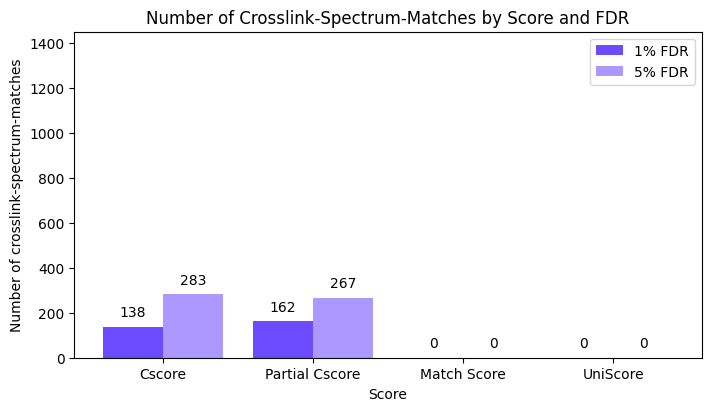

In [13]:
score_names = ("Cscore", "Partial Cscore", "Match Score", "UniScore")
scores = {
    "1% FDR": (
        scores_high["Cscore"],
        scores_high["Partial Cscore"],
        scores_high["Match Score"],
        scores_high["UniScore"],
    ),
    "5% FDR": (
        scores_medium["Cscore"],
        scores_medium["Partial Cscore"],
        scores_medium["Match Score"],
        scores_medium["UniScore"],
    ),
}

x = np.arange(len(score_names))
width = 0.4
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(7, 4))

colors = ["#6d4bff", "#ac99ff"]
for attribute, measurement in scores.items():
    offset = width * multiplier
    rects = ax.bar(
        x + offset, measurement, width, label=attribute, color=colors[multiplier % 2]
    )
    ax.bar_label(rects, padding=5, fmt="{:.0f}")
    multiplier += 1

ax.set_xlabel("Score")
ax.set_ylabel("Number of crosslink-spectrum-matches")
ax.set_title("Number of Crosslink-Spectrum-Matches by Score and FDR")
ax.set_xticks(x + width / 2, score_names)
ax.legend(loc="upper right", ncols=1)
ax.set_ylim(0, 1450)

plt.savefig(
    "plots/CV48/score_comparison_CV48.svg",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
)